## Convolutional Neural Network Model (version 2) with selected features


This notebook is a CNN version of the selected-features neural-network workflow.

Main points from the DNN/embedding workflow:

- Numeric features are log-transformed and scaled, with extra binary indicators for zero-heavy count features.
- Categorical features are passed to the model as raw strings and converted inside Keras with `StringLookup` and trainable `Embedding` layers.
- The concatenated numeric-plus-embedding vector is reshaped into a one-dimensional feature sequence.
- A lightweight 1D CNN learns local feature interactions using `Conv1D`, `BatchNormalization`, `LeakyReLU`, `Dropout`, and `GlobalAveragePooling1D`.
- Optuna optimizes the CNN search space using validation PR AUC metric.
- The final classification threshold is selected on the validation set instead of assuming `0.5`.

Research note: recent tabular/structured-data CNN examples often prefer compact 1D CNNs for vector inputs, with two convolutional blocks, batch normalization, ReLU-family activations, average or max pooling, global average pooling, tuned learning rate/dropout, and a sigmoid or softmax output. This notebook follows that pattern while keeping the architecture intentionally small because tabular features do not have the natural spatial ordering that images have.

References:

- Example 1D CNN design with two convolutional layers, batch normalization, ReLU, global average pooling, and hyperparameter tuning: https://link.springer.com/article/10.1007/s44292-025-00052-8


### Part 1

####  1.1 Importing the necessary libraries and constant variables


If using google colab, use the following code:


In [1]:
run_in_colab = False

In [2]:
def if_colab_run_this():
    import os
    # Clone the repo into Colab's working directory
    !git clone https://github.com/wip-0/ds207_final_project.git /content/ds207_final_project

    # Install optuna in google colab
    !pip install optuna

    # Add project root to Python path so 'src' is importable
    import sys
    sys.path.insert(0, '/content/ds207_final_project')
    # Verify src exists
    from pathlib import Path
    src_path = Path('/content/ds207_final_project/src')
    print(f"src exists: {src_path.exists()}")
    print("src contents:")
    for item in sorted(src_path.iterdir()):
        print(f"  {item.name}")

# apply the function only if you run it in google colab:
if run_in_colab:
    if_colab_run_this()

In [3]:
import os
import json
import tempfile
from pathlib import Path

# custom imports
from src.utils.data_fetch import DataLoader
from src.utils.model_eval.evaluation import evaluate_predictions
from src.visualisations.viz_model import plot_confusion_matrix

# for implementing neural network
import tensorflow as tf
from tensorflow import keras
import random
import re

# other essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# for data preprocessing
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer
from sklearn.pipeline import Pipeline

# various scoring metrics
from sklearn.metrics import (classification_report, accuracy_score,
                             recall_score, precision_score,
                             f1_score, roc_auc_score,
                             average_precision_score)

# for hyperparameter tuning
import optuna
from functools import partial


def find_project_root(start=None):
    current = Path.cwd() if start is None else Path(start).resolve()
    for path in [current, *current.parents]:
        if (path / '.paths').exists() or (path / 'pyproject.toml').exists():
            return path
    return current


# Model and output folder names are kept short and consistent for saved results.
MODEL_NAME = 'cnn_v2_sel_feats'

# export path for the final model and all result files:
project_root = find_project_root()
export_dir = project_root / 'models' / MODEL_NAME
export_dir.mkdir(parents=True, exist_ok=True)

SEED = 1234


/Users/vtsoumpris/PycharmProjects/ds207_final_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


####  1.2 Loading the data

For quickly loading data:

In [4]:
def import_data(version='final_onehot', access= 'remote'):
    """
    Import train, validation, and test datasets.

    Parameters:
    - version: str, one of 'interim', 'final_raw', 'final_label', 'final_onehot'
    - access: str, 'local' or 'remote'
    """

    version_map = {
        'interim': 'interim/split_kf_group_stratified',
        'final_raw': 'final_processed/base_kf/raw',
        'final_label': 'final_processed/base_kf/label',
        'final_onehot': 'final_processed/base_kf/onehot'
    }

    if access == 'remote':
        # Use the DataLoader which handles remote URLs properly
        loader = DataLoader()
        return loader.fetch_data(version=version)

    elif access == 'local':
        import pandas as pd
        from pathlib import Path

        # Find project root (where .paths file is located)
        current = Path.cwd()
        while not (current / '.paths').exists():
            if current.parent == current:
                raise FileNotFoundError("Could not find project root with .paths file")
            current = current.parent

        project_root = current
        data_dir = project_root / 'data' / version_map[version]

        # Check if directory exists
        if not data_dir.exists():
            raise FileNotFoundError(
                f"Data directory does not exist: {data_dir}\n"
                f"Please use access='remote' to download from GitHub, "
                f"or ensure local data is available."
            )

        # Read the CSV files
        df_Xtrain = pd.read_csv(data_dir / 'X_train_mini.csv', low_memory=False)
        df_Xval = pd.read_csv(data_dir / 'X_val.csv', low_memory=False)
        df_Xtest = pd.read_csv(data_dir / 'X_test.csv', low_memory=False)
        df_ytrain = pd.read_csv(data_dir / 'y_train_mini.csv', low_memory=False)
        df_yval = pd.read_csv(data_dir / 'y_val.csv', low_memory=False)
        df_ytest = pd.read_csv(data_dir / 'y_test.csv', low_memory=False)

        print(f"Data imported successfully from: {data_dir}")
        return df_Xtrain, df_Xval, df_Xtest, df_ytrain, df_yval, df_ytest

    else:
        raise ValueError(f"Invalid access type: {access}."
                           f"Choose 'local' or 'remote'")

**Loading the data:**

In [5]:
X_train, X_val, X_test, y_train, y_val, y_test = import_data(version='final_raw',
                                                            access='remote')

Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/X_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/X_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/X_test.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/y_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/y_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/y_test.csv 
Data imported succesfully from paths


In [6]:
X_train.head()

,pipeline_raw__encounter_id,pipeline_raw__max_glu_serum,pipeline_raw__A1Cresult,pipeline_raw__race,pipeline_raw__gender,pipeline_raw__age,pipeline_admission_type_raw__admission_type_id,pipeline_discharge_raw__discharge_disposition_id,pipeline_admission_src_raw__admission_source_id,pipeline_medical_raw__medical_specialty,...,pipeline_prescript_raw__metformin-rosiglitazone,pipeline_prescript_raw__metformin-pioglitazone,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
0,149190,Unknown,Unknown,Caucasian,Female,[10-20),Emergency_Acute,Home,Emergency_Room,Unknown,...,No,No,3,59,0,18,0,0,0,9
1,64410,Unknown,Unknown,AfricanAmerican,Female,[20-30),Emergency_Acute,Home,Emergency_Room,Unknown,...,No,No,2,11,5,13,2,0,1,6
2,500364,Unknown,Unknown,Caucasian,Male,[30-40),Emergency_Acute,Home,Emergency_Room,Unknown,...,No,No,2,44,1,16,0,0,0,7
3,16680,Unknown,Unknown,Caucasian,Male,[40-50),Emergency_Acute,Home,Emergency_Room,Unknown,...,No,No,1,51,0,8,0,0,0,5
4,35754,Unknown,Unknown,Caucasian,Male,[50-60),Emergency_Acute,Home,Referral,Unknown,...,No,No,3,31,6,16,0,0,0,9


In [7]:
y_train.head()

,readmitted
0,1
1,0
2,0
3,0
4,1


####  1.3 Preprocessing and selecting specific features

**Creating a custom preprocessing and input pipeline for the data:**

- The numeric data are log-transformed and scaled to the range `[0, 1]`.
- Zero-heavy numeric count features also get binary `had_*` indicators.
- The categorical data remain as raw string inputs. They are encoded by trainable `StringLookup` + `Embedding` layers inside the Keras Functional API model.
- The CNN itself receives one compact feature sequence created by concatenating numeric values and categorical embeddings.


The definitions below select the numeric and categorical features and prepare train-only categorical vocabularies for Keras embedding layers.


In [8]:
add_prescription_features = False
categorical_features = [
    'pipeline_raw__race',
    'pipeline_raw__age',
    'pipeline_admission_type_raw__admission_type_id',
    'pipeline_discharge_raw__discharge_disposition_id',
    'pipeline_medical_raw__medical_specialty'
]

extra_prescription_features = [
    'pipeline_prescript_raw__chlorpropamide',
    'pipeline_prescript_raw__acetohexamide',
    'pipeline_prescript_raw__miglitol',
    'pipeline_prescript_raw__glimepiride-pioglitazone',
    'pipeline_prescript_raw__metformin-rosiglitazone',
    'pipeline_prescript_raw__metformin-pioglitazone'
]
if add_prescription_features:
    for feature in extra_prescription_features:
        categorical_features.append(feature)

In [9]:
numeric_features = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

zero_heavy_numeric_features = [
    'num_procedures',
    'number_outpatient',
    'number_emergency',
    'number_inpatient'
]

DEFAULT_EMBEDDING_DIM = 5

In [10]:
def safe_layer_name(name):
    return re.sub(r'[^A-Za-z0-9_]+', '_', name)


In [11]:
def target_to_numpy(y):
    if isinstance(y, pd.DataFrame):
        values = y.iloc[:, 0].copy()
    elif isinstance(y, pd.Series):
        values = y.copy()
    else:
        values = pd.Series(np.asarray(y).ravel())

    values = values.replace({'NO': 0, '>30': 1, '<30': 1})
    values = pd.to_numeric(values, errors='raise')

    return values.astype('int32').to_numpy().ravel()


In [12]:
def build_categorical_vocabularies(X_train_raw, categorical_cols):
    vocabularies = {}

    for col in categorical_cols:
        vocabularies[col] = (
            X_train_raw[col]
            .fillna('Unknown')
            .astype(str)
            .drop_duplicates()
            .sort_values()
            .tolist()
        )

    return vocabularies

In [13]:
def prepare_model_inputs(numeric_df, raw_df, categorical_cols):
    inputs = {
        'numeric_features': numeric_df.astype('float32').to_numpy()
    }
    missing_cols = [col for col in categorical_cols if col not in raw_df.columns]
    if missing_cols:
        raise KeyError(f'Missing categorical columns: {missing_cols}')

    for col in categorical_cols:
        values = (
            raw_df[col]
            .fillna('Unknown')
            .astype(str)
            .to_numpy(dtype=object)
            .reshape(-1, 1)
        )
        inputs[col] = tf.convert_to_tensor(values, dtype=tf.string)

    return inputs

Numeric features are transformed with train-only fitting. Zero-heavy count features also get binary indicators.


In [14]:
def numeric_features_pipeline(X_train_raw, X_val_raw, X_test_raw,
                              numeric_cols= numeric_features,
                              zero_heavy_cols= zero_heavy_numeric_features):
    #### PIPELINE for numeric features ####
    # Use log1p because some columns contain zeros:
    # log1p(x) = log(1 + x)
    log_minmax_pipeline = Pipeline(steps=[
        ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
        ('minmax_scaler', MinMaxScaler(feature_range=(0, 1)))
    ])

    X_train_num = log_minmax_pipeline.fit_transform(X_train_raw[numeric_cols])
    X_val_num = log_minmax_pipeline.transform(X_val_raw[numeric_cols])
    X_test_num = log_minmax_pipeline.transform(X_test_raw[numeric_cols])

    X_train_num = pd.DataFrame(X_train_num, columns=numeric_cols, index=X_train_raw.index)
    X_val_num = pd.DataFrame(X_val_num, columns=numeric_cols, index=X_val_raw.index)
    X_test_num = pd.DataFrame(X_test_num, columns=numeric_cols, index=X_test_raw.index)

    # Add zero-vs-nonzero indicators for count features with many zeros.
    indicator_cols = []
    for col in zero_heavy_cols:
        indicator_col = f'had_{col.replace("number_", "")}'
        indicator_cols.append(indicator_col)
        X_train_num[indicator_col] = (X_train_raw[col] > 0).astype('float32')
        X_val_num[indicator_col] = (X_val_raw[col] > 0).astype('float32')
        X_test_num[indicator_col] = (X_test_raw[col] > 0).astype('float32')

    numeric_model_features = numeric_cols + indicator_cols

    return X_train_num, X_val_num, X_test_num, numeric_model_features, log_minmax_pipeline


The final model inputs are dictionaries: one numeric matrix plus one raw `tf.string` tensor for each categorical feature.


In [15]:
def make_input_preview(numeric_df, raw_df, categorical_cols, n=5):
    return pd.concat(
        [
            numeric_df.head(n),
            raw_df[categorical_cols].head(n)
        ],
        axis=1
    )

Build train/validation/test model inputs. The original raw feature frames are kept for categorical model inputs.


In [16]:
# Keep raw dataframes for categorical string inputs.
X_train_raw = X_train.copy()
X_val_raw = X_val.copy()
X_test_raw = X_test.copy()

# Train-only categorical vocabularies for StringLookup layers.
categorical_vocabularies = build_categorical_vocabularies(
    X_train_raw=X_train_raw,
    categorical_cols=categorical_features
)

{feature: len(vocabulary) for feature, vocabulary in categorical_vocabularies.items()}

{'pipeline_raw__race': 6,
 'pipeline_raw__age': 10,
 'pipeline_admission_type_raw__admission_type_id': 4,
 'pipeline_discharge_raw__discharge_disposition_id': 3,
 'pipeline_medical_raw__medical_specialty': 12}

#### Applying the functions to the train, validation, and test sets


In [17]:
# transforming numeric features:
X_train_num, X_val_num, X_test_num, numeric_model_features, numeric_preprocessor = \
numeric_features_pipeline(
    X_train_raw, X_val_raw, X_test_raw
)

X_train_num.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,had_num_procedures,had_outpatient,had_emergency,had_inpatient
0,0.344010,0.810349,0.000000,0.606234,0.000000,0.0,0.000000,0.752051,0.0,0.0,0.0,0.0
1,0.201233,0.426894,0.920782,0.524000,0.292091,0.0,0.224244,0.585385,1.0,1.0,0.0,1.0
2,0.201233,0.741807,0.356207,0.576282,0.000000,0.0,0.000000,0.647781,1.0,0.0,0.0,0.0
3,0.000000,0.776254,0.000000,0.405022,0.000000,0.0,0.000000,0.513354,0.0,0.0,0.0,0.0
4,0.344010,0.660580,1.000000,0.576282,0.000000,0.0,0.000000,0.752051,1.0,0.0,0.0,0.0


In [18]:
# creating Keras model input dictionaries
train_inputs = prepare_model_inputs(X_train_num, X_train_raw, categorical_features)
val_inputs = prepare_model_inputs(X_val_num, X_val_raw, categorical_features)
test_inputs = prepare_model_inputs(X_test_num, X_test_raw, categorical_features)

numeric_input_dim = len(numeric_model_features)
y_train_array = target_to_numpy(y_train)
y_val_array = target_to_numpy(y_val)
y_test_array = target_to_numpy(y_test)

print(f'Numeric input dimension: {numeric_input_dim}')
print(f'Categorical inputs: {len(categorical_features)}')
print(f'Train target distribution: {np.bincount(y_train_array)}')


Numeric input dimension: 12
Categorical inputs: 5
Train target distribution: [31515 28090]


In [19]:
# preview of transformed numeric features plus raw categorical values
make_input_preview(X_train_num, X_train_raw, categorical_features)

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,had_num_procedures,had_outpatient,had_emergency,had_inpatient,pipeline_raw__race,pipeline_raw__age,pipeline_admission_type_raw__admission_type_id,pipeline_discharge_raw__discharge_disposition_id,pipeline_medical_raw__medical_specialty
0,0.344010,0.810349,0.000000,0.606234,0.000000,0.0,0.000000,0.752051,0.0,0.0,0.0,0.0,Caucasian,[10-20),Emergency_Acute,Home,Unknown
1,0.201233,0.426894,0.920782,0.524000,0.292091,0.0,0.224244,0.585385,1.0,1.0,0.0,1.0,AfricanAmerican,[20-30),Emergency_Acute,Home,Unknown
2,0.201233,0.741807,0.356207,0.576282,0.000000,0.0,0.000000,0.647781,1.0,0.0,0.0,0.0,Caucasian,[30-40),Emergency_Acute,Home,Unknown
3,0.000000,0.776254,0.000000,0.405022,0.000000,0.0,0.000000,0.513354,0.0,0.0,0.0,0.0,Caucasian,[40-50),Emergency_Acute,Home,Unknown
4,0.344010,0.660580,1.000000,0.576282,0.000000,0.0,0.000000,0.752051,1.0,0.0,0.0,0.0,Caucasian,[50-60),Emergency_Acute,Home,Unknown


In [20]:
# Keep this variable for compatibility with later summary checks.
# The actual Keras model receives dict inputs: train_inputs, val_inputs, test_inputs.
X_train_model_preview = make_input_preview(X_train_num, X_train_raw, categorical_features)
X_train_model_preview.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,had_num_procedures,had_outpatient,had_emergency,had_inpatient,pipeline_raw__race,pipeline_raw__age,pipeline_admission_type_raw__admission_type_id,pipeline_discharge_raw__discharge_disposition_id,pipeline_medical_raw__medical_specialty
0,0.344010,0.810349,0.000000,0.606234,0.000000,0.0,0.000000,0.752051,0.0,0.0,0.0,0.0,Caucasian,[10-20),Emergency_Acute,Home,Unknown
1,0.201233,0.426894,0.920782,0.524000,0.292091,0.0,0.224244,0.585385,1.0,1.0,0.0,1.0,AfricanAmerican,[20-30),Emergency_Acute,Home,Unknown
2,0.201233,0.741807,0.356207,0.576282,0.000000,0.0,0.000000,0.647781,1.0,0.0,0.0,0.0,Caucasian,[30-40),Emergency_Acute,Home,Unknown
3,0.000000,0.776254,0.000000,0.405022,0.000000,0.0,0.000000,0.513354,0.0,0.0,0.0,0.0,Caucasian,[40-50),Emergency_Acute,Home,Unknown
4,0.344010,0.660580,1.000000,0.576282,0.000000,0.0,0.000000,0.752051,1.0,0.0,0.0,0.0,Caucasian,[50-60),Emergency_Acute,Home,Unknown


#### Part 2 - Initial CNN Model Creation


**2.1** Creating the CNN model using Keras Functional API with trainable categorical embeddings:

The model keeps the same embedding input branch as the attached notebook. After concatenation, the tabular row is reshaped to `(number_of_features, 1)` so `Conv1D` can scan short groups of adjacent engineered features. Because tabular feature order is not as meaningful as pixel order in an image, the CNN is kept small and regularized.


For plotting the loss/auc/recall curves on training and validation sets:

In [21]:
def plot_model_report(history, metrics= None):
    """
    Plot training and validation curves for specified metrics from model training history.
    Examples:
    # Plot single metric
    plot_model_report(history, 'roc_auc')
    # Plot multiple metrics
    plot_model_report(history, ['loss', 'roc_auc', 'recall'])
    # Plot all available metrics (auto-detect)
    plot_model_report(history)
    """

    # Auto-detect metrics if not specified
    if metrics is None:
        # Find all metrics that have validation counterparts
        train_metrics = [k for k in history.keys() if not k.startswith('val_')]
        metrics = [m for m in train_metrics if f'val_{m}' in history.keys()]

        if not metrics:
            raise ValueError("No metrics with validation counterparts found in history")

    # Convert single metric to list
    if isinstance(metrics, str):
        metrics = [metrics]
    # Validate that all metrics exist
    for metric in metrics:
        if metric not in history:
            raise ValueError(f"Metric '{metric}' not found in history. "
                           f"Available metrics: {list(history.keys())}")
        if f'val_{metric}' not in history:
            raise ValueError(f"Validation metric 'val_{metric}' not found in history.")

    # Determine number of subplots
    n_metrics = len(metrics)
    n_cols = min(3, n_metrics)  # Max 3 columns
    n_rows = (n_metrics + n_cols - 1) // n_cols  # Ceiling division
    # Create figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    # Handle single subplot case
    if n_metrics == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_metrics > 1 else [axes]

    # Plot each metric
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        # Create epoch range
        epochs = np.arange(1, len(history[metric]) + 1)
        # Plot training and validation
        ax.plot(epochs, history[metric], lw=2, color='blue', label='Train')
        ax.plot(epochs, history[f'val_{metric}'], lw=2, color='indianred', label='Validation')
        # Formatting
        metric_label = metric.replace('_', ' ').title()
        ax.set_xlabel('Epochs', size=10)
        ax.set_ylabel(metric_label, size=10)
        ax.set_title(f'{metric_label} Plot', fontweight='bold')
        ax.legend(fontsize=10)
        ax.set_xticks(epochs, minor = True)
        ax.set_xlim(1, len(history[metric]))
        ax.grid(True, alpha=0.3)

    # Hide extra subplots if any
    for idx in range(n_metrics, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()

Extracting feature dimensions and checking input consistency:


In [22]:
# creating the numeric feature shape:
numeric_input_dim = len(numeric_model_features)

# checking the shape of the numeric train, validation and test sets:
assert numeric_input_dim == X_val_num.shape[1]
assert numeric_input_dim == X_test_num.shape[1]

# approximate post-concatenation feature width for the default embedding setting.
# This is the sequence length seen by the first Conv1D block when embedding_dim=DEFAULT_EMBEDDING_DIM.
features_shape = numeric_input_dim + len(categorical_features) * DEFAULT_EMBEDDING_DIM
features_shape


37

In [23]:
def create_model_with_embeddings(categorical_vocabularies,
                                 numeric_input_dim,
                                 embedding_dim=DEFAULT_EMBEDDING_DIM,
                                 conv_filters= (64, 32),
                                 kernel_size= 3,
                                 dense_units= 64,
                                 kernel_regularizer= 1e-5,
                                 lr= 1e-3,
                                 dropout_rate= 0.00,
                                 leaky_relu_alpha= 0.2,
                                 pooling_type= 'max',
                                 pool_size= 2,
                                 ):
    """
    Creates and compiles a compact 1D CNN model for binary readmission classification.

    The function keeps the same input idea as the original selected-feature notebook:
    numeric features enter as a float matrix, and categorical features enter as raw strings.
    Each categorical feature is converted to an integer id with `StringLookup`, then to a trainable
    embedding vector. Numeric values and embeddings are concatenated, reshaped into a short
    one-dimensional feature sequence, and passed through SeparableConv1D blocks.

    :param categorical_vocabularies: Dictionary with train-only vocabulary lists for each categorical feature.
    :param numeric_input_dim: Number of numeric model features after preprocessing.
    :param embedding_dim: Embedding width used for every categorical feature.
    :param conv_filters: Tuple/list with the number of filters in each Conv1D block.
    :param kernel_size: Width of the Conv1D kernel over the feature sequence.
    :param dense_units: Number of units in the final dense classification head.
    :param kernel_regularizer: L2 regularization strength, or `None` to disable.
    :param lr: Adam learning rate.
    :param dropout_rate: Dropout rate after convolutional and dense blocks.
    :param leaky_relu_alpha: Negative slope for LeakyReLU.
    :param pooling_type: Type of pooling to use after each convolutional block.
    :param pool_size: Size of the pooling window.
    :return: A compiled TensorFlow Keras model with a sigmoid output.
    """
    # for reproducibility
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)
    tf.keras.utils.set_random_seed(SEED)
    tf.keras.backend.clear_session()

    # initialize L2 regularizer if specified
    regularizer = keras.regularizers.l2(kernel_regularizer) if kernel_regularizer else None

    inputs = {}
    encoded_features = []

    # numeric input layer
    numeric_input = keras.layers.Input(
        shape=(numeric_input_dim,),
        dtype='float32',
        name='numeric_features'
    )
    inputs['numeric_features'] = numeric_input
    encoded_features.append(numeric_input)

    # categorical input layers
    for feature_name, vocabulary in categorical_vocabularies.items():
        layer_prefix = safe_layer_name(feature_name)

        cat_input = keras.layers.Input(
            shape=(1,),
            dtype=tf.string,
            name=feature_name
        )
        inputs[feature_name] = cat_input

        # StringLookup converts raw strings to integer category ids.
        lookup = keras.layers.StringLookup(
            vocabulary= vocabulary,
            mask_token= None,
            num_oov_indices=1,
            name=f'{layer_prefix}_lookup'
        )
        encoded = lookup(cat_input)

        # Embedding lets the model learn compact category representations during training.
        embedded = keras.layers.Embedding(
            input_dim= lookup.vocabulary_size(),
            output_dim= embedding_dim,
            embeddings_initializer= keras.initializers.RandomUniform(seed=SEED),
            embeddings_regularizer= regularizer,
            name= f'{layer_prefix}_embedding'
        )(encoded)

        embedded = keras.layers.Flatten(name=f'{layer_prefix}_embedding_flatten')(embedded)
        encoded_features.append(embedded)

    # concatenating the numeric and categorical features inside the Keras graph
    x = keras.layers.Concatenate(name='numeric_plus_categorical_embeddings')(encoded_features)
    x = keras.layers.BatchNormalization(name='input_batch_norm')(x)

    # Conv1D expects a 3D tensor: (batch, steps, channels).
    # Here, each tabular row becomes a short sequence of feature values with one channel.
    sequence_length = numeric_input_dim + len(categorical_vocabularies) * embedding_dim
    x = keras.layers.Reshape((sequence_length, 1), name='feature_sequence')(x)

    # Small Conv1D blocks work as regularized local feature-interaction extractors.
    for layer_idx, filters in enumerate(conv_filters):
        x = keras.layers.Conv1D(
            filters= filters,
            kernel_size= kernel_size,
            padding='same',
            use_bias=False,
            kernel_initializer= 'he_normal',
            kernel_regularizer= regularizer,
            name=f'conv1d_{layer_idx + 1}'
        )(x)
        x = keras.layers.BatchNormalization(name=f'conv_batch_norm_{layer_idx + 1}')(x)
        x = keras.layers.LeakyReLU(
            negative_slope=leaky_relu_alpha,
            name=f'conv_leaky_relu_{layer_idx + 1}'
        )(x)

        x = keras.layers.Dropout(dropout_rate, name= f'conv_dropout_{layer_idx + 1}')(x)

        if pooling_type == 'max':
                x = keras.layers.MaxPooling1D(
                    pool_size= pool_size,
                    strides= 2,
                    padding='same',
                    name=f'max_pooling_{layer_idx + 1}'
                )(x)
        elif pooling_type == 'average':
                x = keras.layers.AveragePooling1D(
                    pool_size= pool_size,
                    strides= 2,
                    padding='same',
                    name=f'average_pooling_{layer_idx + 1}'
                )(x)
        elif pooling_type is None:
                pass
        else:
                raise ValueError("pooling_type must be one of: 'max', 'average', or None")

    # Global average pooling keeps the model compact and reduces overfitting risk.
    # x = keras.layers.GlobalAveragePooling1D(name='global_average_pooling')(x)

    # Each Conv1D filter is effectively learning small feature-interaction detectors.
    # Average pooling may dilute a strong risk signal if it appears in only one part of the sequence.
    # Max pooling can preserve that strong signal
    avg_pool = keras.layers.GlobalAveragePooling1D(name='global_average_pooling')(x)
    max_pool = keras.layers.GlobalMaxPooling1D(name='global_max_pooling')(x)
    # Concatenating both lets
    # the model use both
    # “overall evidence” and “strongest detected evidence.”
    x = keras.layers.Concatenate()([avg_pool, max_pool])

    # Dense classification head after convolutional feature extraction.
    x = keras.layers.Dense(
        dense_units,
        use_bias= False,
        kernel_initializer='he_normal',
        kernel_regularizer=regularizer,
        name='dense_head'
    )(x)
    x = keras.layers.BatchNormalization(name='dense_head_batch_norm')(x)
    x = keras.layers.LeakyReLU(
        negative_slope=leaky_relu_alpha,
        name='dense_head_leaky_relu'
    )(x)
    x = keras.layers.Dropout(dropout_rate, name='dense_head_dropout')(x)

    # output layer with sigmoid activation function for binary classification
    output = keras.layers.Dense(1, activation='sigmoid', name='readmitted_probability')(x)

    # combine model layers and compile the model
    model = keras.Model(inputs=inputs, outputs=output, name= MODEL_NAME)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate= lr, clipnorm=1.0),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(curve='ROC', name='roc_auc'),
            keras.metrics.AUC(curve='PR', name='pr_auc'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.Precision(name='precision'),
        ],
    )
    return model

In [24]:
def build_model(kernel_regularizer= 1e-5,
                lr= 1e-3,
                drt= 0.00,
                embedding_dim= DEFAULT_EMBEDDING_DIM,
                conv_filters= (128, 64, 32),
                kernel_size= 3,
                dense_units= 64,
                positive_class_weight= 1.0,
                epochs= 30,
                batch_size= 256):
    """
    Builds and trains the initial CNN model with embeddings.

    This function follows the same training structure as the attached notebook:
    create the model, fit on the training split, monitor validation PR AUC,
    and use callbacks for early stopping and learning-rate reduction.
    """

    # create model with embeddings and Conv1D blocks
    model = create_model_with_embeddings(
        categorical_vocabularies= categorical_vocabularies,
        numeric_input_dim= numeric_input_dim,
        embedding_dim= embedding_dim,
        conv_filters= conv_filters,
        kernel_size= kernel_size,
        dense_units= dense_units,
        kernel_regularizer= kernel_regularizer,
        lr= lr,
        dropout_rate= drt,
    )

    # fit the model and create a history object
    history = model.fit(
        train_inputs, y_train_array,
        validation_data= (val_inputs, y_val_array),
        epochs= epochs,
        batch_size= batch_size,
        class_weight= {0: 1.0, 1: positive_class_weight},
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor= 'val_pr_auc',
                mode= 'max',
                patience= 10,
                restore_best_weights= True
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor= 'val_pr_auc',
                mode= 'max',
                factor= 0.5,
                patience= 4,
                min_lr= 1e-5
            ),
        ],
    )

    return model, history


In [25]:
init_model, init_history = build_model()

Epoch 1/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.6599 - pr_auc: 0.6284 - precision: 0.6149 - recall: 0.4987 - roc_auc: 0.6550 - val_loss: 0.6617 - val_pr_auc: 0.6318 - val_precision: 0.6180 - val_recall: 0.5091 - val_roc_auc: 0.6581 - learning_rate: 0.0010
Epoch 2/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.6509 - pr_auc: 0.6433 - precision: 0.6230 - recall: 0.5183 - roc_auc: 0.6693 - val_loss: 0.6531 - val_pr_auc: 0.6417 - val_precision: 0.6200 - val_recall: 0.5323 - val_roc_auc: 0.6658 - learning_rate: 0.0010
Epoch 3/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.6480 - pr_auc: 0.6488 - precision: 0.6284 - recall: 0.5238 - roc_auc: 0.6740 - val_loss: 0.6493 - val_pr_auc: 0.6491 - val_precision: 0.6436 - val_recall: 0.4850 - val_roc_auc: 0.6731 - learning_rate: 0.0010
Epoch 4/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.6462 - pr_auc: 0.6517 - precision: 0.6292 - recall: 0.5268 - roc_auc: 0.6770 - val_loss: 0.6517 - val_pr_auc: 0.6486 - val_p

In [26]:
init_model.summary()

Model: "cnn_v2_sel_feats"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ pipeline_raw__race  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__age   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_admission… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_discharge… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_medical_r… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__race… │ (None, 1)         │          0 │ pipeline_raw__ra… │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__age_… │ (None, 1)         │          0 │ pipeline_raw__ag… │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_admission… │ (None, 1)         │          0 │ pipeline_admissi… │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_discharge… │ (None, 1)         │          0 │ pipeline_dischar… │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_medical_r… │ (None, 1)         │          0 │ pipeline_medical… │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__race… │ (None, 1, 5)      │         35 │ pipeline_raw__ra… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__age_… │ (None, 1, 5)      │         55 │ pipeline_raw__ag… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_admission… │ (None, 1, 5)      │         25 │ pipeline_admissi… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_discharge… │ (None, 1, 5)      │         20 │ pipeline_dischar… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_medical_r… │ (None, 1, 5)      │         65 │ pipeline_medical… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_features    │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__race… │ (None, 5)         │          0 │ pipeline_raw__ra

 Total params: 108,997 (425.77 KB)

 Trainable params: 36,115 (141.07 KB)

 Non-trainable params: 650 (2.54 KB)

 Optimizer params: 72,232 (282.16 KB)

**2.2** Plotting training and validation loss, AUC, recall curves:

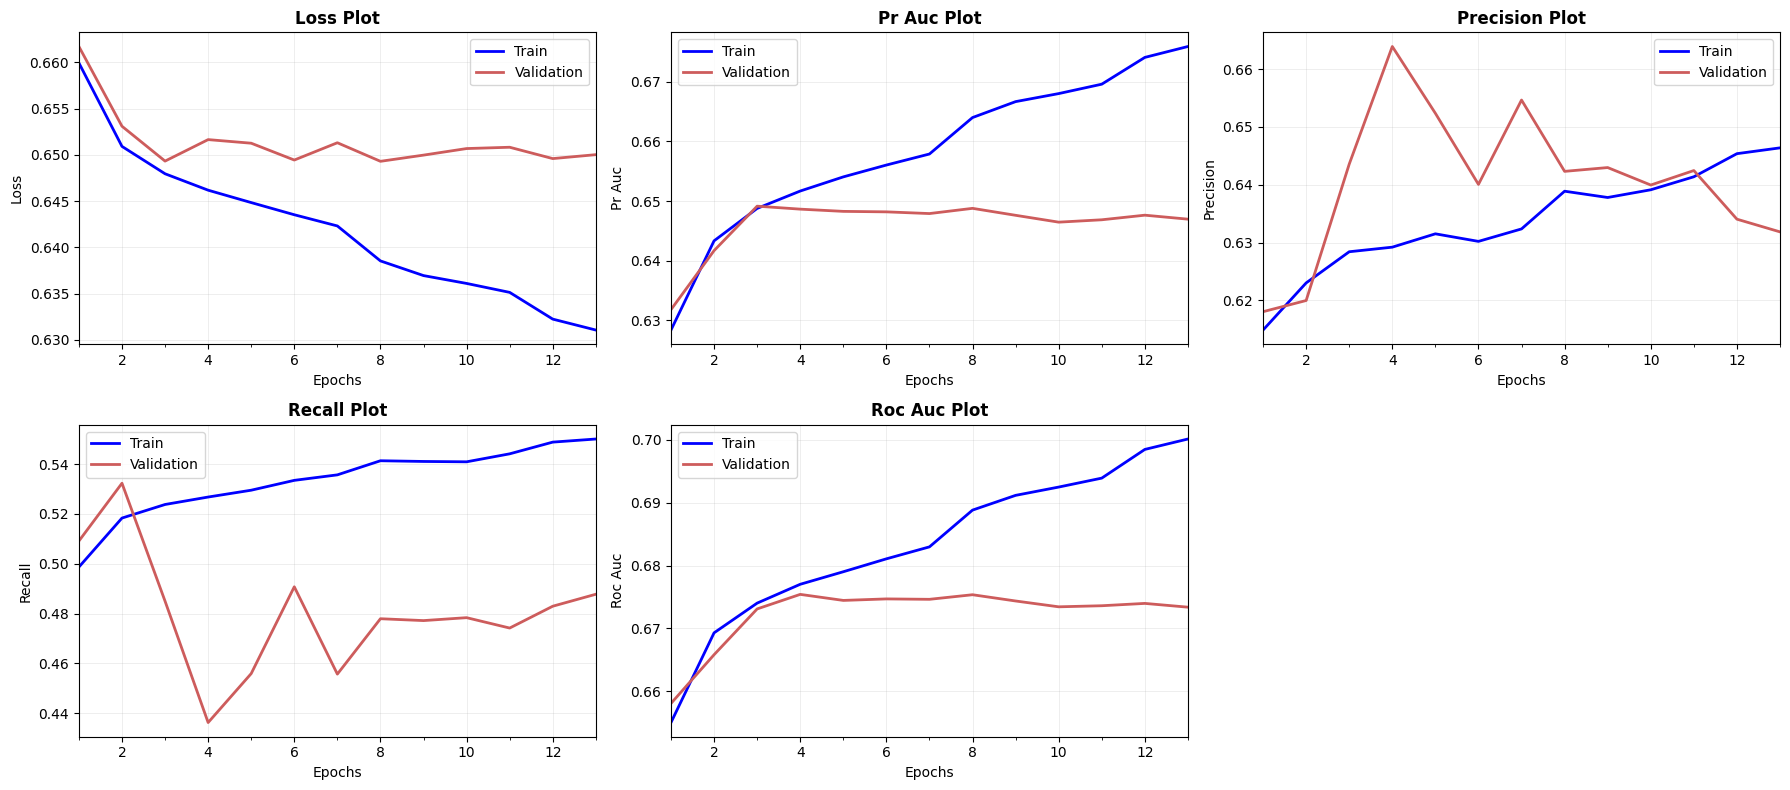

In [27]:
plot_model_report(history= init_history.history)

#### Part 3: Fine-tuning the CNN model using Optuna


**3.1** Defining the trainable-embedding CNN architecture to be optimised:

Optuna tunes the number of convolutional blocks, filters, kernel size, embedding dimension, dense head size, dropout, regularization, learning rate, batch size, and positive-class weight. The objective remains validation PR AUC, matching the attached notebook structure.


In [28]:
def build_model_optuna(trial):

    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)
    tf.keras.utils.set_random_seed(SEED)
    tf.keras.backend.clear_session()

    n_conv_layers = trial.suggest_int('n_conv_layers', 1, 4)
    conv_filters = [
        trial.suggest_categorical(
            f'filters_l{layer_idx + 1}',
            [16, 32, 64, 128]
        )
        for layer_idx in range(n_conv_layers)
    ]

    embedding_dim = trial.suggest_int('embedding_dim', 2, 8)
    kernel_size = trial.suggest_categorical('kernel_size', [3, 5])
    dense_units = trial.suggest_categorical('dense_units', [32, 64, 128])
    kernel_regularizer = trial.suggest_float('kernel_regularizer', 1e-7, 1e-3, log=True)
    lr = trial.suggest_float('learning_rate', 1e-5, 3e-3, log= True)
    drt = trial.suggest_float('dropout_rate', 0.0, 0.5, step= 0.05)
    leaky_relu_alpha = trial.suggest_categorical('LeakyReLU_alpha', [0.05, 0.1, 0.2, 0.3])
    pooling_type = trial.suggest_categorical('pooling_type', ['max', 'average'])

    model = create_model_with_embeddings(
        categorical_vocabularies= categorical_vocabularies,
        numeric_input_dim= numeric_input_dim,
        embedding_dim= embedding_dim,
        conv_filters= conv_filters,
        kernel_size= kernel_size,
        dense_units= dense_units,
        kernel_regularizer= kernel_regularizer,
        lr= lr,
        dropout_rate= drt,
        leaky_relu_alpha= leaky_relu_alpha,
        pooling_type= pooling_type,
    )

    return model


**3.2** Defining fitting function (more hyper-parameters to be optimised):


In [29]:
def fit_model_optuna(trial, model, batch_size, positive_class_weight, epochs= 30, verbose=1):
    history = model.fit(
        train_inputs, y_train_array,
        validation_data= (val_inputs, y_val_array),
        epochs= epochs,
        batch_size= batch_size,
        class_weight= {0: 1.0, 1: positive_class_weight},
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor='val_pr_auc',
                mode='max',
                patience= 8,
                restore_best_weights= True
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_pr_auc',
                mode='max',
                factor= 0.5,
                patience= 3,
                min_lr= 1e-5
            ),
        ],
        verbose= verbose,
    )

    return history

**3.3** Defining the objective function. The study optimizes validation PR AUC directly, which gives more signal than accuracy for this imbalanced binary target.


In [30]:
def objective_fn(trial):
    """
    Defines the objective function for an Optuna optimization trial. The function configures the
    model and its parameters, evaluates its performance, and stores the best results for analysis.
    """
    batch_size = trial.suggest_categorical('batch_size', [128, 256])
    positive_class_weight = trial.suggest_float('positive_class_weight', 1.0, 1.4, step= 0.05)

    # build and fit the model
    model = build_model_optuna(trial)
    history = fit_model_optuna(
        trial,
        model,
        batch_size= batch_size,
        positive_class_weight= positive_class_weight,
    )

    # the objective is to maximize the validation PR-AUC
    val_pr_auc = history.history['val_pr_auc']
    best_epoch_idx = int(np.argmax(val_pr_auc))

    # set attributes for the Optuna trial
    trial.set_user_attr('best_epoch', best_epoch_idx + 1)
    trial.set_user_attr('best_val_pr_auc', float(history.history['val_pr_auc'][best_epoch_idx]))
    trial.set_user_attr('best_val_roc_auc', float(history.history['val_roc_auc'][best_epoch_idx]))
    trial.set_user_attr('best_val_recall', float(history.history['val_recall'][best_epoch_idx]))
    trial.set_user_attr('best_val_precision', float(history.history['val_precision'][best_epoch_idx]))

    return float(history.history['val_pr_auc'][best_epoch_idx])

**3.4** Running the optimization (study):

In [31]:
def extract_best_params(study):
    """
    Extract the best parameters from a completed Optuna study.
    """
    completed_trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
    ]
    if not completed_trials:
        raise ValueError('No completed Optuna trials available. Run study.optimize first.')

    return study.best_params

In [32]:
# to load the existing study
# (saved under the model folder as a SQLite db format)
load_existing_study = False

###### ###### ######
storage_path = f"sqlite:///{export_dir / 'optuna_study_2.db'}"
num_trials = 100
sec_timeout = 3600

In [33]:
# create study (or load an existing one)
study = optuna.create_study(
    study_name='cnn_sel_feats_optuna_2',
    direction= 'maximize',
    storage=storage_path,
    load_if_exists= True,
)

# checking if the study has already been completed
completed_trials = [
    trial for trial in study.trials
    if trial.state == optuna.trial.TrialState.COMPLETE
]

# Run optimization unless explicitly loading an existing study that already has results.
if (not load_existing_study) or (len(completed_trials) == 0):
    study.optimize(func= objective_fn,
                   n_trials= num_trials,
                   timeout= sec_timeout)

[I 2026-07-24 15:04:30,489] A new study created in RDB with name: cnn_sel_feats_optuna_2


Epoch 1/30
466/466 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.8046 - pr_auc: 0.6067 - precision: 0.5421 - recall: 0.7107 - roc_auc: 0.6365 - val_loss: 0.6668 - val_pr_auc: 0.6359 - val_precision: 0.6323 - val_recall: 0.4822 - val_roc_auc: 0.6607 - learning_rate: 0.0022
Epoch 2/30
466/466 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7859 - pr_auc: 0.6286 - precision: 0.5543 - recall: 0.7190 - roc_auc: 0.6558 - val_loss: 0.6668 - val_pr_auc: 0.6408 - val_precision: 0.5816 - val_recall: 0.6328 - val_roc_auc: 0.6624 - learning_rate: 0.0022
Epoch 3/30
466/466 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7785 - pr_auc: 0.6354 - precision: 0.5543 - recall: 0.7262 - roc_auc: 0.6606 - val_loss: 0.6559 - val_pr_auc: 0.6432 - val_precision: 0.6235 - val_recall: 0.5212 - val_roc_auc: 0.6669 - learning_rate: 0.0022
Epoch 4/30
466/466 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7750 - pr_auc: 0.6362 - precision: 0.5559 - recall: 0.7297 - roc_auc: 0.6628 - val_loss: 0.6551 - val_pr_auc: 0.6430 - val_preci

[I 2026-07-24 15:05:30,135] Trial 0 finished with value: 0.6511794328689575 and parameters: {'batch_size': 128, 'positive_class_weight': 1.4, 'n_conv_layers': 1, 'filters_l1': 32, 'embedding_dim': 6, 'kernel_size': 3, 'dense_units': 128, 'kernel_regularizer': 7.496582607740011e-05, 'learning_rate': 0.0022014664399725176, 'dropout_rate': 0.05, 'LeakyReLU_alpha': 0.2, 'pooling_type': 'average'}. Best is trial 0 with value: 0.6511794328689575.


Epoch 1/30
466/466 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - loss: 1.0161 - pr_auc: 0.5358 - precision: 0.5413 - recall: 0.3261 - roc_auc: 0.5546 - val_loss: 0.8676 - val_pr_auc: 0.5979 - val_precision: 0.6301 - val_recall: 0.3532 - val_roc_auc: 0.6167 - learning_rate: 1.8671e-05
Epoch 2/30
466/466 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.9806 - pr_auc: 0.5563 - precision: 0.5564 - recall: 0.3686 - roc_auc: 0.5762 - val_loss: 0.8656 - val_pr_auc: 0.6069 - val_precision: 0.6388 - val_recall: 0.3319 - val_roc_auc: 0.6308 - learning_rate: 1.8671e-05
Epoch 3/30
466/466 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.9642 - pr_auc: 0.5618 - precision: 0.5631 - recall: 0.4004 - roc_auc: 0.5828 - val_loss: 0.8608 - val_pr_auc: 0.6121 - val_precision: 0.6370 - val_recall: 0.3548 - val_roc_auc: 0.6388 - learning_rate: 1.8671e-05
Epoch 4/30
466/466 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.9510 - pr_auc: 0.5705 - precision: 0.5610 - recall: 0.4309 - roc_auc: 0.5905 - val_loss: 0.8574 - val_pr_auc: 0

[I 2026-07-24 15:09:32,771] Trial 1 finished with value: 0.6449849605560303 and parameters: {'batch_size': 128, 'positive_class_weight': 1.15, 'n_conv_layers': 4, 'filters_l1': 128, 'filters_l2': 128, 'filters_l3': 16, 'filters_l4': 128, 'embedding_dim': 7, 'kernel_size': 5, 'dense_units': 32, 'kernel_regularizer': 0.00022896140688774896, 'learning_rate': 1.8670857560402456e-05, 'dropout_rate': 0.25, 'LeakyReLU_alpha': 0.05, 'pooling_type': 'average'}. Best is trial 0 with value: 0.6511794328689575.


...

[I 2026-07-24 16:02:21,735] Trial 35 finished with value: 0.6524626612663269 and parameters: {'batch_size': 128, 'positive_class_weight': 1.3, 'n_conv_layers': 4, 'filters_l1': 16, 'filters_l2': 128, 'filters_l3': 128, 'filters_l4': 64, 'embedding_dim': 7, 'kernel_size': 3, 'dense_units': 128, 'kernel_regularizer': 1.0611288259639157e-07, 'learning_rate': 0.0003230241692979752, 'dropout_rate': 0.15000000000000002, 'LeakyReLU_alpha': 0.05, 'pooling_type': 'max'}. Best is trial 20 with value: 0.6550909280776978.


Epoch 1/30
466/466 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.7312 - pr_auc: 0.6062 - precision: 0.5673 - recall: 0.6050 - roc_auc: 0.6361 - val_loss: 0.6565 - val_pr_auc: 0.6374 - val_precision: 0.6505 - val_recall: 0.4132 - val_roc_auc: 0.6593 - learning_rate: 6.5906e-04
Epoch 2/30
466/466 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.7159 - pr_auc: 0.6280 - precision: 0.5813 - recall: 0.6130 - roc_auc: 0.6555 - val_loss: 0.6464 - val_pr_auc: 0.6450 - val_precision: 0.6445 - val_recall: 0.4744 - val_roc_auc: 0.6712 - learning_rate: 6.5906e-04
Epoch 3/30
466/466 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.7116 - pr_auc: 0.6355 - precision: 0.5871 - recall: 0.6248 - roc_auc: 0.6626 - val_loss: 0.6434 - val_pr_auc: 0.6474 - val_precision: 0.6410 - val_recall: 0.4836 - val_roc_auc: 0.6734 - learning_rate: 6.5906e-04
Epoch 4/30
466/466 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.7093 - pr_auc: 0.6384 - precision: 0.5887 - recall: 0.6276 - roc_auc: 0.6663 - val_loss: 0.6416 - val_pr_auc: 0.6500

[I 2026-07-24 16:03:13,901] Trial 36 finished with value: 0.6527180671691895 and parameters: {'batch_size': 128, 'positive_class_weight': 1.2, 'n_conv_layers': 3, 'filters_l1': 16, 'filters_l2': 16, 'filters_l3': 128, 'embedding_dim': 7, 'kernel_size': 5, 'dense_units': 128, 'kernel_regularizer': 2.775150792678239e-07, 'learning_rate': 0.000659063210511329, 'dropout_rate': 0.05, 'LeakyReLU_alpha': 0.05, 'pooling_type': 'average'}. Best is trial 20 with value: 0.6550909280776978.


Epoch 1/30
466/466 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.7676 - pr_auc: 0.5944 - precision: 0.5483 - recall: 0.6425 - roc_auc: 0.6213 - val_loss: 0.6601 - val_pr_auc: 0.6409 - val_precision: 0.6014 - val_recall: 0.5564 - val_roc_auc: 0.6633 - learning_rate: 0.0025
Epoch 2/30
466/466 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.7453 - pr_auc: 0.6271 - precision: 0.5651 - recall: 0.6726 - roc_auc: 0.6545 - val_loss: 0.6547 - val_pr_auc: 0.6449 - val_precision: 0.5805 - val_recall: 0.6480 - val_roc_auc: 0.6679 - learning_rate: 0.0025
Epoch 3/30
466/466 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.7424 - pr_auc: 0.6322 - precision: 0.5647 - recall: 0.6913 - roc_auc: 0.6590 - val_loss: 0.6546 - val_pr_auc: 0.6477 - val_precision: 0.5728 - val_recall: 0.6813 - val_roc_auc: 0.6712 - learning_rate: 0.0025
Epoch 4/30
466/466 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.7402 - pr_auc: 0.6355 - precision: 0.5650 - recall: 0.6962 - roc_auc: 0.6619 - val_loss: 0.6520 - val_pr_auc: 0.6481 - val_preci

[I 2026-07-24 16:04:59,393] Trial 37 finished with value: 0.6525973677635193 and parameters: {'batch_size': 128, 'positive_class_weight': 1.3, 'n_conv_layers': 4, 'filters_l1': 16, 'filters_l2': 64, 'filters_l3': 128, 'filters_l4': 64, 'embedding_dim': 3, 'kernel_size': 3, 'dense_units': 32, 'kernel_regularizer': 5.01092143821918e-07, 'learning_rate': 0.0025200351254357606, 'dropout_rate': 0.25, 'LeakyReLU_alpha': 0.05, 'pooling_type': 'max'}. Best is trial 20 with value: 0.6550909280776978.


In [34]:
# extracting best parameters from the study
best_params = extract_best_params(study)
best_params

{'batch_size': 256,
 'positive_class_weight': 1.3,
 'n_conv_layers': 4,
 'filters_l1': 32,
 'filters_l2': 64,
 'filters_l3': 128,
 'filters_l4': 64,
 'embedding_dim': 5,
 'kernel_size': 5,
 'dense_units': 64,
 'kernel_regularizer': 3.134133109630341e-07,
 'learning_rate': 0.00018821227422721848,
 'dropout_rate': 0.1,
 'LeakyReLU_alpha': 0.2,
 'pooling_type': 'average'}

**3.5** Creating the final fine-tuned CNN model:


In [35]:
def build_model_fine_tuned(best_parameters= best_params,
                           fit_model= True,
                           epochs= 30,
                           verbose= 1):
    # setting the seed for reproducibility
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)
    tf.keras.utils.set_random_seed(SEED)
    tf.keras.backend.clear_session()

    n_conv_layers = best_parameters['n_conv_layers']
    conv_filters = [
        best_parameters[f'filters_l{layer_idx + 1}']
        for layer_idx in range(n_conv_layers)
    ]

    model = create_model_with_embeddings(
        categorical_vocabularies= categorical_vocabularies,
        numeric_input_dim= numeric_input_dim,
        embedding_dim= best_parameters['embedding_dim'],
        conv_filters= conv_filters,
        kernel_size= best_parameters['kernel_size'],
        dense_units= best_parameters['dense_units'],
        kernel_regularizer= best_parameters['kernel_regularizer'],
        lr= best_parameters['learning_rate'],
        dropout_rate= best_parameters['dropout_rate'],
        leaky_relu_alpha= best_parameters['LeakyReLU_alpha'],
        pooling_type =  best_parameters['pooling_type']
    )

    history = None
    if fit_model:
        history = model.fit(
            train_inputs, y_train_array,
            validation_data= (val_inputs, y_val_array),
            epochs= epochs,
            batch_size= best_parameters['batch_size'],
            class_weight= {0: 1.0, 1: best_parameters['positive_class_weight']},
            callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor='val_pr_auc',
                    mode='max',
                    patience= 10,
                    restore_best_weights=True
                ),
                keras.callbacks.ReduceLROnPlateau(
                    monitor='val_pr_auc',
                    mode='max',
                    factor= 0.5,
                    patience= 4,
                    min_lr= 1e-5
                ),
            ],
            verbose=verbose,
        )

    return model, history


**Getting the structure of the model without fitting it first**:

In [36]:
model_finetuned, _ = build_model_fine_tuned(
    best_parameters= best_params,
    fit_model= False,
    epochs= 30,
    verbose= 1
)
model_finetuned.summary()

Model: "cnn_v2_sel_feats"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ pipeline_raw__race  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__age   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_admission… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_discharge… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_medical_r… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__race… │ (None, 1)         │          0 │ pipeline_raw__ra… │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__age_… │ (None, 1)         │          0 │ pipeline_raw__ag… │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_admission… │ (None, 1)         │          0 │ pipeline_admissi… │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_discharge… │ (None, 1)         │          0 │ pipeline_dischar… │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_medical_r… │ (None, 1)         │          0 │ pipeline_medical… │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__race… │ (None, 1, 5)      │         35 │ pipeline_raw__ra… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__age_… │ (None, 1, 5)      │         55 │ pipeline_raw__ag… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_admission… │ (None, 1, 5)      │         25 │ pipeline_admissi… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_discharge… │ (None, 1, 5)      │         20 │ pipeline_dischar… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_medical_r… │ (None, 1, 5)      │         65 │ pipeline_medical… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_features    │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pipeline_raw__race… │ (None, 5)         │          0 │ pipeline_raw__ra

 Total params: 102,333 (399.74 KB)

 Trainable params: 101,555 (396.70 KB)

 Non-trainable params: 778 (3.04 KB)

**Fitting the fine-tuned model**:

In [37]:
model_finetuned, history_fine_tuned = build_model_fine_tuned(
    best_parameters= best_params,
    fit_model= True,
    epochs= 30, # best epoch based on loss and PR-AUC plots
    verbose= 1
)


Epoch 1/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.7852 - pr_auc: 0.5830 - precision: 0.5667 - recall: 0.5111 - roc_auc: 0.6125 - val_loss: 0.7020 - val_pr_auc: 0.6234 - val_precision: 0.4764 - val_recall: 0.9879 - val_roc_auc: 0.6545 - learning_rate: 1.8821e-04
Epoch 2/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.7572 - pr_auc: 0.6083 - precision: 0.5639 - recall: 0.6429 - roc_auc: 0.6415 - val_loss: 0.6867 - val_pr_auc: 0.6391 - val_precision: 0.5220 - val_recall: 0.8490 - val_roc_auc: 0.6637 - learning_rate: 1.8821e-04
Epoch 3/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.7511 - pr_auc: 0.6180 - precision: 0.5658 - recall: 0.6508 - roc_auc: 0.6490 - val_loss: 0.6569 - val_pr_auc: 0.6460 - val_precision: 0.5794 - val_recall: 0.6649 - val_roc_auc: 0.6700 - learning_rate: 1.8821e-04
Epoch 4/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.7495 - pr_auc: 0.6199 - precision: 0.5686 - recall: 0.6593 - roc_auc: 0.6521 - val_loss: 0.6469 - val_pr_auc: 0.

**Plotting AUC, Recall and Loss of the fine-tuned CNN model (train & validation set)**:


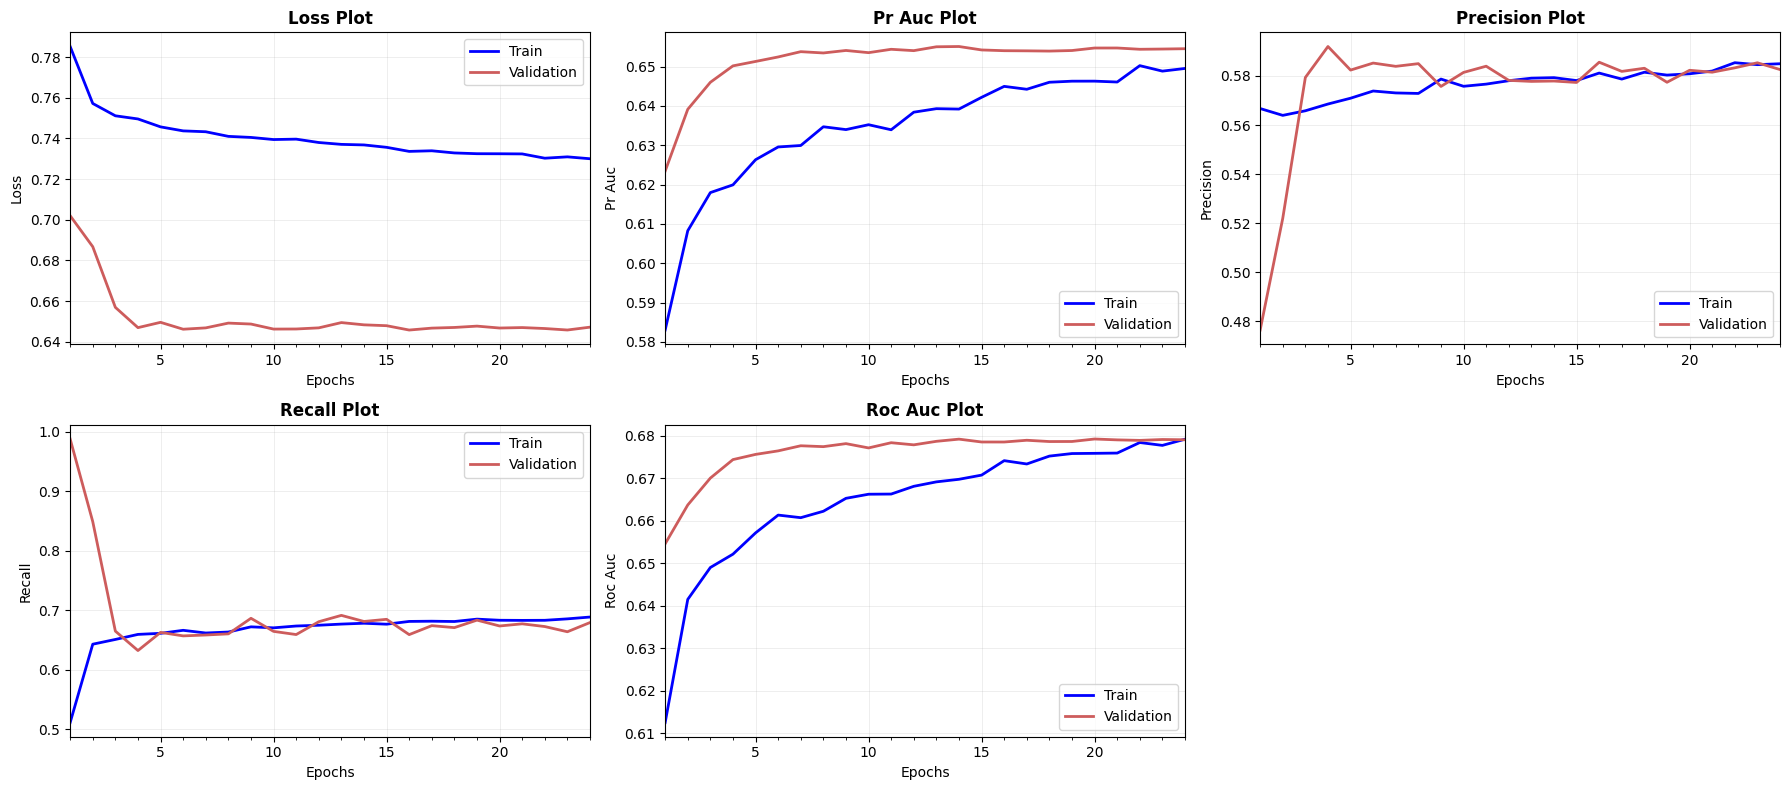

In [38]:
plot_model_report(history= history_fine_tuned.history)

### Part 4: Choosing a validation-set threshold and converting predictions to binary


In [39]:
def find_best_threshold(y_true, y_proba, metric= 'f1', min_precision= None):
    """
    Finds the optimal probability threshold for binary classification based on a given metric,
    while optionally enforcing a minimum precision constraint.

    Given the true binary labels and the predicted probabilities, this function evaluates various
    threshold values and calculates their corresponding performance metrics (precision, recall, F1-score,
    accuracy). It allows the user to specify whether the optimization should prioritize a particular metric,
    such as 'f1', 'recall', or 'precision'. Optionally, a minimum precision threshold can be enforced,
    which will exclude thresholds that do not satisfy the precision requirement.

    :param y_true: Array-like of shape (n_samples,) containing the ground-truth binary labels. Input data is
        expected to be in binary {0, 1} format.
    :param y_proba: Array-like of shape (n_samples,) containing the predicted probabilities for the positive
        class (class 1). Probabilities should be in the range [0.0, 1.0].
    :param metric: Optional string value specifying the performance metric to optimize. Default is 'f1'.
        Allowed values include 'f1', 'precision', 'recall', and 'pr_auc'.
        PR-AUC is calculated from the predicted probabilities and is therefore threshold-independent;
        when metric='pr_auc', F1-score is used as the tie-breaker for selecting a threshold.
    :param min_precision: Optional float value specifying the minimum precision constraint. If provided,
        thresholds that result in a precision below this value will be penalized by assigning a negative
        infinity score.

    :return: A tuple containing two elements:
        - Best threshold value (float) optimizing the specified metric.
        - A pandas DataFrame containing detailed performance metrics (threshold, precision, recall,
          F1-score, accuracy, and score) for all evaluated thresholds across the range [0.05, 0.95].
    """
    y_true = np.asarray(y_true).ravel()
    y_proba = np.asarray(y_proba).ravel()
    valid_metrics = {'f1', 'precision', 'recall', 'pr_auc'}
    if metric not in valid_metrics:
        raise ValueError(f"metric must be one of {sorted(valid_metrics)}")

    pr_auc = average_precision_score(y_true, y_proba)
    thresholds = np.linspace(0.05, 0.95, 181)

    rows = []
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        precision = precision_score(y_true, y_pred, zero_division= 0)
        recall = recall_score(y_true, y_pred, zero_division= 0)
        f1 = f1_score(y_true, y_pred, zero_division= 0)
        accuracy = accuracy_score(y_true, y_pred)

        if metric == 'recall':
            score = recall
        elif metric == 'precision':
            score = precision
        elif metric == 'pr_auc':
            score = pr_auc
        else:
            score = f1

        if min_precision is not None and precision < min_precision:
            score = -np.inf

        rows.append({
            'threshold': threshold,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'accuracy': accuracy,
            'pr_auc': pr_auc,
            'score': score,
        })

    threshold_results = pd.DataFrame(rows)
    sort_columns = ['score', 'f1_score'] if metric == 'pr_auc' else ['score']
    best_row = threshold_results.sort_values(sort_columns, ascending=False).iloc[0]

    return float(best_row['threshold']), threshold_results

1863/1863 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
621/621 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Best validation threshold: 0.365


,threshold,precision,recall,f1_score,accuracy,pr_auc,score
0,0.050,0.471237,1.000000,0.640599,0.471237,0.655123,0.655123
114,0.620,0.663210,0.430311,0.521959,0.628567,0.655123,0.655123
116,0.630,0.668578,0.410873,0.508963,0.626403,0.655123,0.655123
117,0.635,0.673393,0.402756,0.504043,0.626504,0.655123,0.655123
118,0.640,0.676535,0.392930,0.497129,0.625396,0.655123,0.655123


              precision    recall  f1-score   support

           0       0.76      0.23      0.35     31515
           1       0.51      0.92      0.66     28090

    accuracy                           0.55     59605
   macro avg       0.64      0.57      0.50     59605
weighted avg       0.64      0.55      0.49     59605

              precision    recall  f1-score   support

           0       0.76      0.24      0.36     10506
           1       0.52      0.91      0.66      9363

    accuracy                           0.56     19869
   macro avg       0.64      0.58      0.51     19869
weighted avg       0.64      0.56      0.50     19869



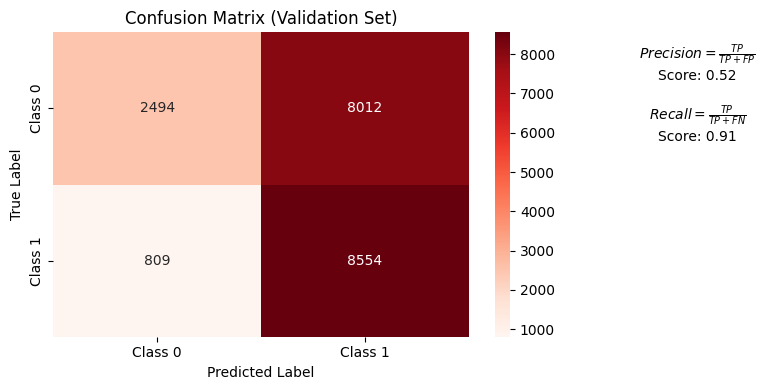

In [40]:
# after training the model
ypred_train_proba = model_finetuned.predict(train_inputs).ravel()
ypred_val_proba = model_finetuned.predict(val_inputs).ravel()

# Select threshold on validation set only.
best_threshold, threshold_results = find_best_threshold(
    y_true=y_val_array,
    y_proba=ypred_val_proba,
    metric='pr_auc'
)

print(f'Best validation threshold: {best_threshold:.3f}')
display(threshold_results.sort_values('score', ascending=False).head())

# converting to binary predictions
ypred_train_binary = (ypred_train_proba >= best_threshold).astype(int).flatten()
ypred_val_binary = (ypred_val_proba >= best_threshold).astype(int).flatten()

# Now evaluate using your evaluation function
recall_tr, precision_tr, f1_tr, acc_tr, cl_report_tr = \
    evaluate_predictions(true_values=y_train,
                         predictions=ypred_train_binary,
                         print_class_report=True)

recall_vl, precision_vl, f1_vl, acc_vl, cl_report_vl = \
    evaluate_predictions(true_values=y_val,
                         predictions=ypred_val_binary,
                         print_class_report=True)

# Plot confusion matrix (validation set)
scores = plot_confusion_matrix(y_true=y_val['readmitted'],
                               y_pred=ypred_val_binary,
                               fig_size= (8, 4),
                               title='Confusion Matrix (Validation Set)',
                               colour_map='Reds')


### Part 5: Test Set Evaluation

Generating predictions on test data...
621/621 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Test set size: 19869 samples
Predictions generated: 19869
Classification threshold: 0.365

              precision    recall  f1-score   support

           0       0.75      0.23      0.36     10506
           1       0.52      0.91      0.66      9363

    accuracy                           0.55     19869
   macro avg       0.63      0.57      0.51     19869
weighted avg       0.64      0.55      0.50     19869



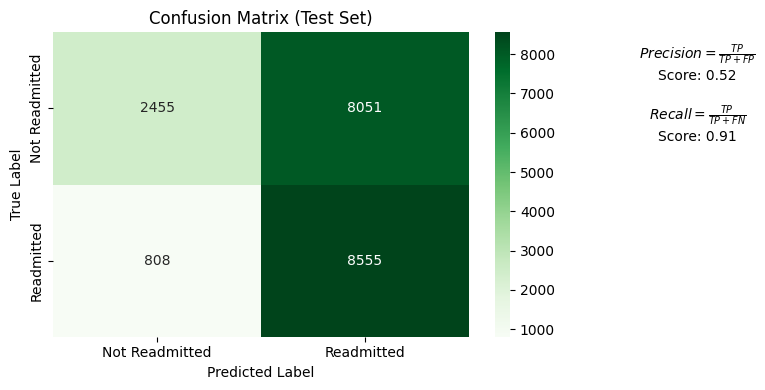

In [41]:
# Generate predictions on test set
print('Generating predictions on test data...')
ypred_test_proba = model_finetuned.predict(test_inputs).ravel()

# Convert to binary predictions using the validation-selected threshold.
ypred_test_binary = (ypred_test_proba >= best_threshold).astype(int).flatten()

print(f'Test set size: {len(y_test)} samples')
print(f'Predictions generated: {len(ypred_test_binary)}')
print(f'Classification threshold: {best_threshold:.3f}')
print()

# Classification Report:
recall_test, precision_test, f1_test, acc_test, cl_report_test = (
    evaluate_predictions(true_values=y_test,
                         predictions=ypred_test_binary,
                         print_class_report=True)
)

# confusion matrix
scores_test = plot_confusion_matrix(y_true=y_test['readmitted'],
                                    y_pred=ypred_test_binary,
                                    fig_size=(8, 4),
                                    class_names=['Not Readmitted', 'Readmitted'],
                                    title='Confusion Matrix (Test Set)',
                                    colour_map='Greens')


In [42]:
# Summarising evaluation metrics
print()
print('-' * 30)
print('TEST SET PERFORMANCE SUMMARY')
print('-' * 30)
print(f'Threshold: {best_threshold:.3f}')
print(f'Accuracy:  {acc_test:.4f}')
print(f'Recall:    {recall_test:.4f}')
print(f'Precision: {precision_test:.4f}')
print(f'F1-Score:  {f1_test:.4f}')
print('-' * 30)
print()

# storing results for comparison
test_results = {
    'dataset': 'test',
    'n_samples': len(y_test),
    'threshold': best_threshold,
    'accuracy': acc_test,
    'recall': recall_test,
    'precision': precision_test,
    'f1_score': f1_test,
    'confusion_matrix': scores_test['confusion_matrix']
}



------------------------------
TEST SET PERFORMANCE SUMMARY
------------------------------
Threshold: 0.365
Accuracy:  0.5541
Recall:    0.9137
Precision: 0.5152
F1-Score:  0.6589
------------------------------



In [43]:
test_results

{'dataset': 'test',
 'n_samples': 19869,
 'threshold': 0.36499999999999994,
 'accuracy': 0.5541295485429564,
 'recall': 0.9137028730107871,
 'precision': 0.5151752378658316,
 'f1_score': 0.6588624898917941,
 'confusion_matrix': array([[2455, 8051],
        [ 808, 8555]])}

**Saving the model and result files:**

The Keras model, Optuna trials, best hyperparameters, threshold search table, and test-set summary are saved under `models/cnn_sel_feats/`.


In [44]:
MODEL_PATH = export_dir / f"{MODEL_NAME}_finetuned.keras"
model_finetuned.save(MODEL_PATH)

# Save the Optuna trial history for later comparison.
optuna_trials_path = export_dir / f"{MODEL_NAME}_optuna_trials.csv"
study.trials_dataframe().to_csv(optuna_trials_path, index=False)

# Save the best hyperparameters as a readable JSON file.
best_params_path = export_dir / f"{MODEL_NAME}_best_params.json"
with open(best_params_path, 'w') as f:
    json.dump(best_params, f, indent=2)

# Save all validation thresholds so the chosen threshold can be audited later.
threshold_results_path = export_dir / f"{MODEL_NAME}_threshold_results.csv"
threshold_results.to_csv(threshold_results_path, index=False)

# Convert NumPy values to plain Python values before writing JSON.
test_results_to_save = {
    key: (value.tolist() if hasattr(value, 'tolist') else value)
    for key, value in test_results.items()
}

test_results_path = export_dir / f"{MODEL_NAME}_test_results.json"
with open(test_results_path, 'w') as f:
    json.dump(test_results_to_save, f, indent=2)

print(f"Model saved to: {MODEL_PATH.resolve()}")
print(f"Optuna trials saved to: {optuna_trials_path.resolve()}")
print(f"Best parameters saved to: {best_params_path.resolve()}")
print(f"Threshold results saved to: {threshold_results_path.resolve()}")
print(f"Test results saved to: {test_results_path.resolve()}")


Model saved to: /Users/vtsoumpris/PycharmProjects/ds207_final_project/models/cnn_v2_sel_feats/cnn_v2_sel_feats_finetuned.keras
Optuna trials saved to: /Users/vtsoumpris/PycharmProjects/ds207_final_project/models/cnn_v2_sel_feats/cnn_v2_sel_feats_optuna_trials.csv
Best parameters saved to: /Users/vtsoumpris/PycharmProjects/ds207_final_project/models/cnn_v2_sel_feats/cnn_v2_sel_feats_best_params.json
Threshold results saved to: /Users/vtsoumpris/PycharmProjects/ds207_final_project/models/cnn_v2_sel_feats/cnn_v2_sel_feats_threshold_results.csv
Test results saved to: /Users/vtsoumpris/PycharmProjects/ds207_final_project/models/cnn_v2_sel_feats/cnn_v2_sel_feats_test_results.json
